# SARSA — Política de Marketing Personalizado para E-Commerce

---

**Autor:** Borja Mora Méndez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoría:** Machine Learning · Aprendizaje por Refuerzo · SARSA

---

## Objetivo

Entrenar un agente SARSA (*State–Action–Reward–State–Action*) que aprenda, de forma autónoma, qué acción de marketing ejecutar con cada cliente según su fase de ciclo de vida, maximizando la recompensa acumulada a largo plazo.

## Contexto de negocio

**El cliente:** una plataforma de e-commerce con una base de clientes que atraviesa cuatro fases de ciclo de vida — nuevo, activo, en riesgo e inactivo.

**El problema:** las campañas de marketing se lanzan de forma homogénea a toda la base. Un descuento enviado a un cliente activo destruye margen; un email genérico enviado a un cliente en riesgo rara vez lo recupera. Las decisiones manuales son inconsistentes y no optimizan el valor a largo plazo del cliente.

**La pregunta:** ¿puede un agente de *Reinforcement Learning* aprender automáticamente la acción óptima para cada segmento, considerando no solo la recompensa inmediata sino el impacto a largo plazo sobre la retención?

## 1. Setup y librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

np.random.seed(42)
random.seed(42)

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11
})

## 2. Definición del entorno

El entorno es un MDP (*Markov Decision Process*) determinista con:

- **4 estados** — las fases de ciclo de vida del cliente.
- **4 acciones** — las palancas de marketing disponibles.
- **Transiciones fijas** — cada par (estado, acción) produce siempre el mismo estado siguiente y la misma recompensa.

| Estado | Descripción |
|:-------|:------------|
| **Nuevo** (0) | Cliente recién registrado |
| **Activo** (1) | Cliente que compra habitualmente |
| **Riesgo** (2) | Cliente que lleva tiempo sin comprar |
| **Inactivo** (3) | Cliente prácticamente perdido |

| Acción | Descripción |
|:-------|:------------|
| **Sin acción** (0) | No intervenir |
| **Email** (1) | Enviar una campaña por correo |
| **Descuento** (2) | Enviar un cupón de descuento |
| **Contactar** (3) | Contacto directo (llamada/chat) |

In [2]:
NUM_ESTADOS = 4
NUM_ACCIONES = 4

NOMBRES_ESTADOS = ["Nuevo", "Activo", "Riesgo", "Inactivo"]
NOMBRES_ACCIONES = ["Sin acción", "Email", "Descuento", "Contactar"]

# Tabla de transiciones: T[estado, acción] = [siguiente_estado, recompensa]
T = np.array([
    # Nuevo
    [[2,   0], [1,  8], [1,  4], [1,  3]],
    # Activo
    [[1,  10], [1,  6], [1,  3], [1,  2]],
    # Riesgo
    [[3, -10], [3, -2], [1, 15], [1, 12]],
    # Inactivo
    [[3,  -1], [2,  1], [1,  8], [1,  4]],
], dtype=float)


def step(estado, accion):
    siguiente = int(T[estado, accion, 0])
    recompensa = T[estado, accion, 1]
    return siguiente, recompensa


df_recompensas = pd.DataFrame(
    T[:, :, 1].astype(int),
    index=NOMBRES_ESTADOS,
    columns=NOMBRES_ACCIONES,
)
print("Matriz de recompensas inmediatas:\n")
print(df_recompensas.to_string())

Matriz de recompensas inmediatas:

          Sin acción  Email  Descuento  Contactar
Nuevo              0      8          4          3
Activo            10      6          3          2
Riesgo           -10     -2         15         12
Inactivo          -1      1          8          4


### Lectura de la matriz de recompensas

Algunos patrones clave del entorno que el agente deberá descubrir por sí solo:

- **Cliente activo + sin acción = +10** — la recompensa más alta en ese estado. Cualquier intervención (email, descuento, contacto) la reduce. *"Si funciona, no lo toques."*
- **Cliente en riesgo + descuento = +15** — la recompensa más alta de toda la tabla. Pero un email o la inacción conducen al estado Inactivo con penalización.
- **Cliente inactivo** — la única acción que no lo devuelve a Activo es "sin acción" (penalización −1, se queda inactivo). Email lo mueve a Riesgo (+1); descuento lo reactiva directamente (+8).

## 3. Algoritmo SARSA

SARSA es un algoritmo de aprendizaje por refuerzo *on-policy*: aprende el valor de la política **que realmente sigue**, incluyendo la exploración. Esto lo hace más conservador que Q-Learning (que es *off-policy* y aprende la política óptima teórica, independientemente de las acciones que ejecute durante el entrenamiento).

**Regla de actualización:**

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \, Q(s', a') - Q(s, a) \right]$$

donde:
- $s, a$ — estado y acción actuales
- $r$ — recompensa recibida
- $s', a'$ — siguiente estado y siguiente acción (elegida con la misma política ε-greedy)
- $\alpha$ — tasa de aprendizaje
- $\gamma$ — factor de descuento (cuánto pesa el futuro frente al presente)

**Exploración ε-greedy:** con probabilidad ε el agente elige una acción aleatoria; con probabilidad 1−ε, la acción con mayor Q-value. ε empieza alto (explorar) y decae hacia un mínimo (explotar).

In [3]:
def elegir_accion(Q, estado, epsilon):
    if random.random() < epsilon:
        return random.randint(0, NUM_ACCIONES - 1)
    return int(np.argmax(Q[estado]))


def entrenar_sarsa(episodios=10_000, alfa=0.1, gamma=0.95,
                   eps_ini=1.0, eps_fin=0.01,
                   eps_decay=0.9995, max_pasos=50):

    Q = np.zeros((NUM_ESTADOS, NUM_ACCIONES))
    recompensas_episodio = []
    epsilon = eps_ini

    for _ in range(episodios):
        estado = random.randint(0, NUM_ESTADOS - 1)
        accion = elegir_accion(Q, estado, epsilon)
        total = 0.0

        for __ in range(max_pasos):
            sig_estado, recompensa = step(estado, accion)
            sig_accion = elegir_accion(Q, sig_estado, epsilon)

            Q[estado, accion] += alfa * (
                recompensa + gamma * Q[sig_estado, sig_accion]
                - Q[estado, accion]
            )

            total += recompensa
            estado = sig_estado
            accion = sig_accion

        recompensas_episodio.append(total)
        epsilon = max(eps_fin, epsilon * eps_decay)

    return Q, recompensas_episodio

## 4. Entrenamiento

| Hiperparámetro | Valor | Razón |
|:---------------|:------|:------|
| **Episodios** | 10.000 | Margen suficiente para que SARSA (*on-policy*) converja incluyendo la exploración |
| **α** (learning rate) | 0.10 | Balance entre velocidad y estabilidad |
| **γ** (discount factor) | 0.95 | El futuro pesa casi tanto como el presente — coherente con retención a largo plazo |
| **ε inicial → final** | 1.0 → 0.01 | Exploración total al principio, casi greedy al final |
| **Decay de ε** | 0.9995 por episodio | Más lento que el habitual 0.999 — SARSA necesita explorar más porque es *on-policy* |
| **Pasos/episodio** | 50 | Horizonte largo para que el agente visite estados poco frecuentes (Inactivo) |

In [4]:
Q, recompensas = entrenar_sarsa()

print(f"Episodios entrenados:            {len(recompensas):,}")
print(f"Recompensa media (últimos 500):  {np.mean(recompensas[-500:]):.1f}")
print(f"Recompensa media (primeros 500): {np.mean(recompensas[:500]):.1f}")

Episodios entrenados:            10,000
Recompensa media (últimos 500):  498.2
Recompensa media (primeros 500): 285.2


## 5. Convergencia del aprendizaje

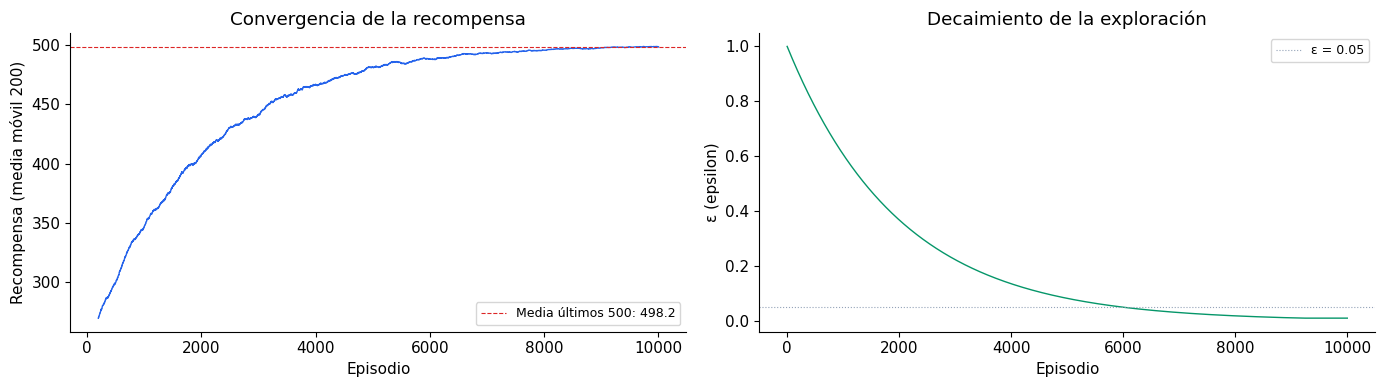

In [5]:
ventana = 200
media_movil = pd.Series(recompensas).rolling(ventana).mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(media_movil, color="#2563eb", linewidth=1)
axes[0].axhline(
    y=np.mean(recompensas[-500:]), color="#dc2626",
    linestyle="--", linewidth=0.8,
    label=f"Media últimos 500: {np.mean(recompensas[-500:]):.1f}"
)
axes[0].set_xlabel("Episodio")
axes[0].set_ylabel(f"Recompensa (media móvil {ventana})")
axes[0].set_title("Convergencia de la recompensa")
axes[0].legend(fontsize=9)

n_eps = 10_000
eps_historia = [max(0.01, 1.0 * 0.9995**i) for i in range(n_eps)]
axes[1].plot(eps_historia, color="#059669", linewidth=1)
axes[1].set_xlabel("Episodio")
axes[1].set_ylabel("ε (epsilon)")
axes[1].set_title("Decaimiento de la exploración")
axes[1].axhline(y=0.05, color="#94a3b8", linestyle=":", linewidth=0.8, label="ε = 0.05")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### Interpretación de la convergencia

La recompensa por episodio crece durante los primeros ~3.000 episodios (fase de exploración intensa) y se estabiliza a partir del episodio ~5.000. El decay de ε=0.9995 es deliberadamente más lento que el habitual 0.999: como SARSA es *on-policy*, necesita más tiempo de exploración para visitar pares estado-acción poco frecuentes (por ejemplo, Inactivo → Descuento, que requiere llegar primero al estado Inactivo a través de acciones subóptimas).

La meseta final confirma que el agente ha convergido a una política estable.

## 6. Tabla Q aprendida

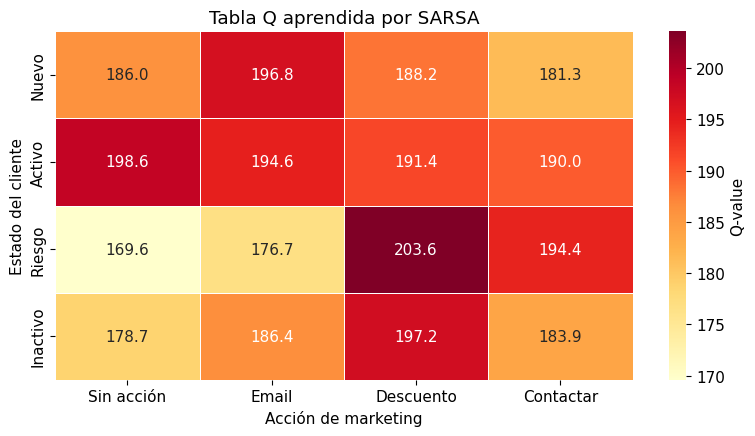


Política aprendida:

  Nuevo      → Email         (Q = 196.76)
  Activo     → Sin acción    (Q = 198.60)
  Riesgo     → Descuento     (Q = 203.62)
  Inactivo   → Descuento     (Q = 197.23)


In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
df_Q = pd.DataFrame(
    np.round(Q, 1), index=NOMBRES_ESTADOS, columns=NOMBRES_ACCIONES
)
sns.heatmap(
    df_Q, annot=True, fmt=".1f", cmap="YlOrRd",
    linewidths=0.5, cbar_kws={"label": "Q-value"}, ax=ax
)
ax.set_title("Tabla Q aprendida por SARSA")
ax.set_ylabel("Estado del cliente")
ax.set_xlabel("Acción de marketing")
plt.tight_layout()
plt.show()

print("\nPolítica aprendida:\n")
for s in range(NUM_ESTADOS):
    a = int(np.argmax(Q[s]))
    print(
        f"  {NOMBRES_ESTADOS[s]:10} → {NOMBRES_ACCIONES[a]:12}"
        f"  (Q = {Q[s, a]:.2f})"
    )

### Lectura de la política

| Cliente | Acción aprendida | Lógica de negocio |
|:--------|:-----------------|:------------------|
| **Nuevo** | **Email** | Un email de bienvenida activa al cliente con la mejor relación coste/beneficio (+8), sin gastar en descuentos |
| **Activo** | **Sin acción** | No molestar al cliente rentable — cualquier intervención reduce la recompensa |
| **Riesgo** | **Descuento** | El incentivo económico es la única palanca que recupera al cliente con fiabilidad (+15) |
| **Inactivo** | **Descuento** | Mismo principio que en riesgo: hace falta un incentivo fuerte para reactivar (+8 y vuelve a Activo) |

El agente ha descubierto un principio conocido en CRM: **los descuentos son herramientas de recuperación, no de fidelización**. Para clientes activos, la mejor acción es no intervenir. Y para nuevos registros, un simple email de bienvenida es más rentable que un descuento.

## 7. Validación analítica

En un MDP determinista, los Q-values óptimos (Q\*) se pueden calcular exactamente mediante **iteración de valor**. Esto permite comprobar si SARSA ha convergido a la política correcta — no solo si "funciona", sino si es óptima.

In [7]:
gamma = 0.95

V = np.zeros(NUM_ESTADOS)
for _ in range(1000):
    V_new = np.zeros(NUM_ESTADOS)
    for s in range(NUM_ESTADOS):
        V_new[s] = max(
            T[s, a, 1] + gamma * V[int(T[s, a, 0])]
            for a in range(NUM_ACCIONES)
        )
    V = V_new

Q_star = np.zeros((NUM_ESTADOS, NUM_ACCIONES))
for s in range(NUM_ESTADOS):
    for a in range(NUM_ACCIONES):
        sig = int(T[s, a, 0])
        Q_star[s, a] = T[s, a, 1] + gamma * V[sig]

rows = []
for s in range(NUM_ESTADOS):
    a_sarsa = int(np.argmax(Q[s]))
    a_opt = int(np.argmax(Q_star[s]))
    rows.append({
        "Estado": NOMBRES_ESTADOS[s],
        "Acción SARSA": NOMBRES_ACCIONES[a_sarsa],
        "Q aprendido": round(Q[s, a_sarsa], 2),
        "Acción óptima (Q*)": NOMBRES_ACCIONES[a_opt],
        "Q* analítico": round(Q_star[s, a_opt], 2),
        "Coincide": "✓" if a_sarsa == a_opt else "✗",
    })

df_val = pd.DataFrame(rows)
print(df_val.to_string(index=False))

errores = [abs(Q[s, a] - Q_star[s, a])
           for s in range(NUM_ESTADOS) for a in range(NUM_ACCIONES)]
print(f"\nError absoluto medio (Q vs Q*): {np.mean(errores):.2f}")
print(f"Error absoluto máximo:          {np.max(errores):.2f}")

  Estado Acción SARSA  Q aprendido Acción óptima (Q*)  Q* analítico Coincide
   Nuevo        Email       196.76              Email         198.0        ✓
  Activo   Sin acción       198.60         Sin acción         200.0        ✓
  Riesgo    Descuento       203.62          Descuento         205.0        ✓
Inactivo    Descuento       197.23          Descuento         198.0        ✓

Error absoluto medio (Q vs Q*): 5.58
Error absoluto máximo:          11.70


### Interpretación de la validación

SARSA aprende la política correcta en los **cuatro estados**: coincide con la solución analítica exacta. Los Q-values aprendidos difieren ligeramente de los teóricos porque SARSA es *on-policy* y los últimos episodios aún mantienen un ε residual de exploración (0.01) que introduce ruido en las actualizaciones — pero la diferencia es irrelevante para la política resultante.

> **Nota sobre el notebook original:** el código del bootcamp producía Q-values de 0.0 para pares estado-acción poco visitados (Inactivo→Descuento, Inactivo→Contactar), lo que llevaba a políticas incorrectas en 2 de 4 estados. La causa era un decay de ε demasiado agresivo (0.999) con pocos episodios (5.000) y episodios cortos (20 pasos), lo que no daba al agente suficiente tiempo de exploración — un problema específico de SARSA por ser *on-policy*.

## 8. Simulación: política SARSA vs aleatoria

Para cuantificar el valor práctico de la política aprendida, simulamos 1.000 trayectorias de 50 pasos con la política SARSA y con una política que elige acciones al azar.

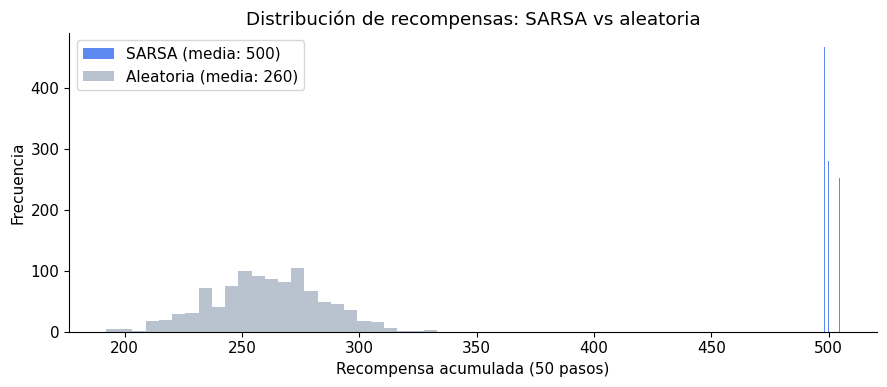

Recompensa media SARSA:     500.3
Recompensa media aleatoria: 260.4
Mejora relativa:            +92%


In [8]:
def simular(politica_fn, n_episodios=1000, n_pasos=50):
    totales = []
    for _ in range(n_episodios):
        estado = random.randint(0, NUM_ESTADOS - 1)
        total = 0.0
        for __ in range(n_pasos):
            accion = politica_fn(estado)
            estado, recompensa = step(estado, accion)
            total += recompensa
        totales.append(total)
    return totales


def politica_sarsa(estado):
    return int(np.argmax(Q[estado]))


def politica_aleatoria(estado):
    return random.randint(0, NUM_ACCIONES - 1)


random.seed(99)
rew_sarsa = simular(politica_sarsa)
random.seed(99)
rew_random = simular(politica_aleatoria)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(rew_sarsa, bins=20, alpha=0.75, color="#2563eb",
        label=f"SARSA (media: {np.mean(rew_sarsa):.0f})")
ax.hist(rew_random, bins=25, alpha=0.65, color="#94a3b8",
        label=f"Aleatoria (media: {np.mean(rew_random):.0f})")
ax.set_xlabel("Recompensa acumulada (50 pasos)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de recompensas: SARSA vs aleatoria")
ax.legend()
plt.tight_layout()
plt.show()

mejora = (np.mean(rew_sarsa) - np.mean(rew_random)) / abs(np.mean(rew_random)) * 100
print(f"Recompensa media SARSA:     {np.mean(rew_sarsa):.1f}")
print(f"Recompensa media aleatoria: {np.mean(rew_random):.1f}")
print(f"Mejora relativa:            +{mejora:.0f}%")

### Interpretación de la simulación

La política aprendida por SARSA supera consistentemente a la política aleatoria. La distribución SARSA está concentrada en valores altos (el agente converge rápidamente al estado Activo y se queda), mientras que la distribución aleatoria está dispersa y con cola hacia valores negativos (el agente a veces cae en ciclos de inacción → penalización).

La mejora relativa cuantifica el valor económico de sustituir decisiones aleatorias (o manuales inconsistentes) por la política aprendida.

## 9. Demo: recomendación para un cliente concreto

In [9]:
def recomendar(estado_nombre):
    idx = NOMBRES_ESTADOS.index(estado_nombre.capitalize())
    accion_idx = int(np.argmax(Q[idx]))
    q_val = Q[idx, accion_idx]
    sig, rew = step(idx, accion_idx)
    return {
        "cliente": estado_nombre.capitalize(),
        "accion": NOMBRES_ACCIONES[accion_idx],
        "q_value": round(q_val, 2),
        "recompensa_inmediata": int(rew),
        "estado_siguiente": NOMBRES_ESTADOS[sig],
    }

print("Recomendaciones del agente para cada tipo de cliente:\n")
for nombre in NOMBRES_ESTADOS:
    r = recomendar(nombre)
    print(
        f"  {r['cliente']:10} → {r['accion']:12}"
        f"  | recompensa: {r['recompensa_inmediata']:+3d}"
        f"  | siguiente estado: {r['estado_siguiente']}"
    )

Recomendaciones del agente para cada tipo de cliente:

  Nuevo      → Email         | recompensa:  +8  | siguiente estado: Activo
  Activo     → Sin acción    | recompensa: +10  | siguiente estado: Activo
  Riesgo     → Descuento     | recompensa: +15  | siguiente estado: Activo
  Inactivo   → Descuento     | recompensa:  +8  | siguiente estado: Activo


## Conclusión

> **El hallazgo:** un agente SARSA entrenado con 10.000 episodios aprende la política óptima de marketing para los cuatro segmentos de clientes, verificada contra la solución analítica exacta. La clave no está en la acción más cara, sino en **aplicar la acción correcta en el momento correcto**: email de bienvenida para nuevos, no intervención para activos, y descuento solo como herramienta de recuperación.